# Week 10 workshop · Prisoner's Dilemma and evolutionary change

<span class="workshop-download-enabled" aria-hidden="true"></span>


# Context


**Canonical game:** Prisoner's Dilemma.  
**Modelling practice:** distinguish tournament performance from evolutionary success.  
**New toolkit:** history-dependent strategies, payoff translated into reproductive success, inheritance and mutation.


# Specify the model

The same game appears at four levels: a one-shot encounter, a repeated match, a tournament of fixed strategies and an evolving population. The canonical game remains the Prisoner's Dilemma; selection and mutation are the extension.

| Ingredient | Baseline choice |
|---|---|
| Players and actions | two players; cooperate ($C$) or defect ($D$) |
| Payoffs | a stated $2\times2$ Prisoner's Dilemma matrix |
| Repeated strategies | Always Cooperate, Always Defect and Tit for Tat |
| Population | well mixed; strategy frequencies sum to one |
| Clock | rounds within matches; generations within evolution |
| Update | all expected payoffs are calculated from the same current population |
| Inheritance | above-average payoff increases expected copies |
| Variation | a stated mutation rate |
| Outputs | match scores and strategy frequencies through generations |

## Pseudocode · strategy and population updates

```text
CONTRACT strategy(own_history, opponent_history) -> C or D

PLAY a repeated match:
    initialise histories and scores
    each round, let both strategies choose from the same current histories
    record realised actions and add the corresponding payoffs
    return mean scores

EVOLVE a population:
    initialise strategy frequencies and record generation zero
    each generation, calculate every strategy's payoff against the current mixture
    copy strategies in proportion to the declared payoff-to-fitness rule
    apply mutation, normalise frequencies and record the new population
```

Before implementation, state the payoff values, first move, selection equation, mutation rule, initial frequencies and generation budget.


### Numerical evolution

Generations form a discrete clock. Calculate all expected payoffs from one current population, then replace the population together so loop order cannot change the result. The baseline is well mixed and has no physical boundary. Record generation zero and every subsequent strategy-frequency vector.


# Implement and test

The baseline first constructs the repeated-game payoff matrix. The assertions check familiar encounters before those scores are used in population evolution.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

names = ["Always cooperate", "Always defect", "Tit for Tat"]
payoff = {(0, 0): (3, 3), (0, 1): (0, 5),
          (1, 0): (5, 0), (1, 1): (1, 1)}

def action(strategy, own, other):
    if strategy == 0: return 0
    if strategy == 1: return 1
    return 0 if not other else other[-1]

def match(a, b, rounds=30):
    ha, hb, scores = [], [], np.zeros(2)
    for _ in range(rounds):
        aa, ab = action(a, ha, hb), action(b, hb, ha)
        scores += payoff[aa, ab]
        ha.append(aa); hb.append(ab)
    return scores / rounds

A = np.empty((3, 3))
for i in range(3):
    for j in range(3):
        A[i, j] = match(i, j)[0]
A


assert np.allclose(A[0, 0], 3)
assert np.allclose(A[1, 0], 5)
assert np.allclose(A[2, 2], 3)


# Simulate and inspect

## One population history

Run one declared initial population. Inspect the full trajectory rather than only its final dominant strategy. This establishes a working baseline, not a general evolutionary result.


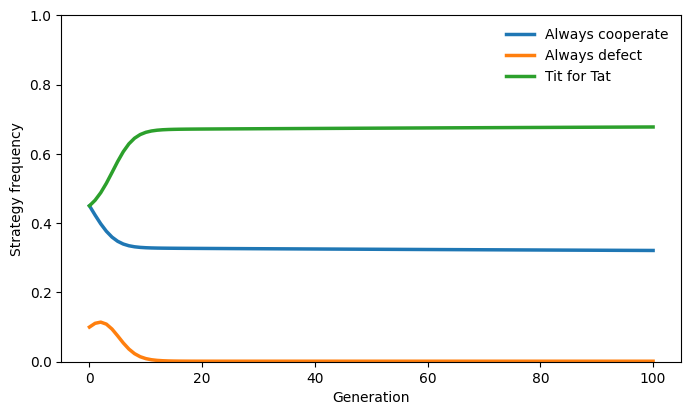

In [2]:
def evolve(initial=(0.45, 0.10, 0.45), generations=100,
           selection_strength=1.0, mutation_rate=0.002):
    x = np.asarray(initial, dtype=float)
    x /= x.sum()
    history = [x.copy()]
    for _ in range(generations):
        fitness = A @ x
        reproductive_weight = np.exp(selection_strength * fitness)
        x = x * reproductive_weight
        x /= x.sum()
        x = (1 - mutation_rate) * x + mutation_rate / len(x)
        history.append(x.copy())
    return np.asarray(history)

history = evolve()
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, name in enumerate(names):
    ax.plot(history[:, i], label=name, linewidth=2.5)
ax.set(xlabel="Generation", ylabel="Strategy frequency", ylim=(0, 1))
ax.legend(frameon=False)
plt.show()


# Analyse

## Compare controlled initial conditions

Keep the payoffs, selection rule, mutation and generation budget fixed. Change only the initial strategy frequencies. The same update is then being tested in different population contexts.


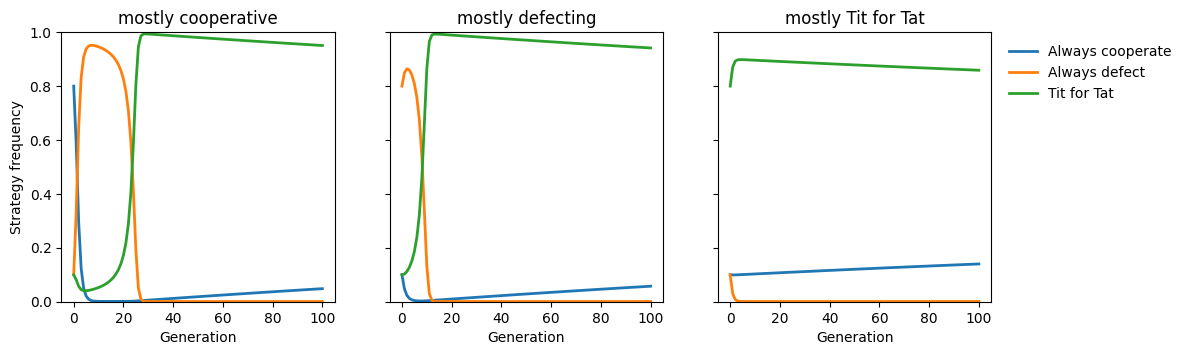

In [3]:
initial_populations = {
    "mostly cooperative": (0.80, 0.10, 0.10),
    "mostly defecting": (0.10, 0.80, 0.10),
    "mostly Tit for Tat": (0.10, 0.10, 0.80),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
for ax, (label, initial) in zip(axes, initial_populations.items()):
    trial = evolve(initial=initial)
    for strategy, name in enumerate(names):
        ax.plot(trial[:, strategy], label=name, linewidth=2)
    ax.set(title=label, xlabel="Generation", ylim=(0, 1))

axes[0].set_ylabel("Strategy frequency")
axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


## Decide what the comparison supports

A high tournament score describes performance against the opponents included in that tournament. Evolutionary success means becoming or remaining common while the population of opponents changes.

Use the histories to assess three distinct questions:

- Can a rare cooperative strategy invade a population of defectors?
- Can it resist invasion after it becomes common?
- Does the conclusion depend on mutation or initial composition?

The deterministic update is a discrete counterpart of replicator dynamics. A spatial or network extension changes both encounter and replacement structure, so it answers a different question.


# Project studio

## Design the investigation

Choose either one controlled extension to the evolutionary game or the next investigation required by your project. Write its workshop spine before adding code:

1. **Context:** the question and why the model or data can address it.
2. **Specify:** state, world or data, initialisation, update and outputs.
3. **Pseudocode:** enough detail for another person to reproduce the process.
4. **Implement and test:** one check with a known or interpretable result.
5. **Simulate and inspect:** a direct view that can expose incorrect behaviour.
6. **Analyse:** one justified individual-, system- or ensemble-level measure.
7. **Extend:** one change while the baseline remains controlled.
8. **Exit:** one supported claim, one limitation and the next check.

Do not fill every heading for symmetry. Include only the steps needed to make the investigation reproducible and the conclusion defensible.


## Consultation checkpoint

Before leaving, show a working baseline or state precisely what prevents it from running. Use the compact model audit to review the investigation:

1. What is represented?
2. What has been left out?
3. How was the implementation checked?
4. What was measured?
5. What was it compared with?
6. What claim is supported?

Record one result, one unresolved modelling decision and the next check you will perform.


# Exit

Submit or retain your investigation spine. It should make clear what is inherited, what you changed, what evidence will answer the question and which decision still needs justification.
